# 🛒 Ecommerce Data Analysis

## Project Overview

This project analyzes an ecommerce dataset to understand sales
performance, customer behavior, product performance, order patterns,
and business trends.

The analysis is performed using Python, Pandas, NumPy, Matplotlib,
and Seaborn.

## Objectives

- Analyze overall ecommerce sales performance
- Identify the best-performing product categories
- Analyze customer segments
- Study order status and payment methods
- Analyze monthly sales trends
- Identify top-performing products
- Understand customer purchasing behavior
- Create meaningful data visualizations

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
file_path = "clean_final_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 49222
Number of columns: 17


In [31]:
df.head()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          49222 non-null  int64  
 1   CustomerID       49222 non-null  int64  
 2   OrderDate        49222 non-null  object 
 3   ProductID        49222 non-null  int64  
 4   Quantity         49222 non-null  float64
 5   Discount         49222 non-null  float64
 6   PaymentMethod    49222 non-null  object 
 7   Status           49222 non-null  object 
 8   Age              49222 non-null  float64
 9   City             49222 non-null  object 
 10  SignupDate       49222 non-null  object 
 11  CustomerSegment  49222 non-null  object 
 12  ProductName      49222 non-null  object 
 13  Category         49222 non-null  object 
 14  UnitPrice        49222 non-null  float64
 15  Sales            49222 non-null  float64
 16  OrderValue       49222 non-null  float64
dtypes: float64(6

In [33]:
df.describe()

,OrderID,CustomerID,ProductID,Quantity,Discount,Age,UnitPrice,Sales,OrderValue
count,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000
mean,525007.608366,105002.304356,2009.460160,1.881923,7.485576,41.283369,40.286579,69.985576,69.985576
std,14435.345449,2888.912895,5.578603,1.079382,7.754378,13.681355,42.613062,94.483273,94.483273
min,500001.000000,100001.000000,2001.000000,-2.000000,0.000000,18.000000,7.000000,-170.000000,-170.000000
25%,512507.250000,102504.000000,2004.000000,1.000000,0.000000,29.000000,11.000000,17.000000,17.000000
50%,525016.500000,105005.000000,2008.000000,2.000000,5.000000,41.000000,28.000000,38.000000,38.000000
75%,537506.750000,107497.000000,2014.000000,2.000000,10.000000,53.000000,58.000000,84.000000,84.000000
max,550000.000000,110000.000000,2020.000000,5.000000,30.000000,65.000000,260.000000,1300.000000,1300.000000


## 6. Data Quality Check

Before performing the analysis, the dataset is checked for missing
values, duplicate records, incorrect data types, and other data-quality
issues.

In [11]:

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
OrderID            0
CustomerID         0
OrderDate          0
ProductID          0
Quantity           0
Discount           0
PaymentMethod      0
Status             0
Age                0
City               0
SignupDate         0
CustomerSegment    0
ProductName        0
Category           0
UnitPrice          0
Sales              0
OrderValue         0
dtype: int64


In [35]:


duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [36]:
# Check data types

print(df.dtypes)

OrderID              int64
CustomerID           int64
OrderDate           object
ProductID            int64
Quantity           float64
Discount           float64
PaymentMethod       object
Status              object
Age                float64
City                object
SignupDate          object
CustomerSegment     object
ProductName         object
Category            object
UnitPrice          float64
Sales              float64
OrderValue         float64
dtype: object


In [12]:
# Convert date columns to datetime

df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["SignupDate"] = pd.to_datetime(df["SignupDate"])

print("Date columns converted successfully!")

Date columns converted successfully!


In [13]:
print(df[["OrderDate", "SignupDate"]].dtypes)

OrderDate     datetime64[ns]
SignupDate    datetime64[ns]
dtype: object


In [14]:
print("Order Status:")
print(df["Status"].value_counts())

print("\nCustomer Segments:")
print(df["CustomerSegment"].value_counts())

print("\nProduct Categories:")
print(df["Category"].value_counts())

print("\nPayment Methods:")
print(df["PaymentMethod"].value_counts())

Order Status:
Status
Completed    45276
Cancelled     2438
Returned      1508
Name: count, dtype: int64

Customer Segments:
CustomerSegment
Regular    27296
New        17056
VIP         4870
Name: count, dtype: int64

Product Categories:
Category
Accessories    18189
Electronics    17765
Stationery      5440
Home Office     3122
Wearables       3043
Gaming          1663
Name: count, dtype: int64

Payment Methods:
PaymentMethod
Gateway       23894
CardToCard    11744
Wallet         8661
Cash           4923
Name: count, dtype: int64


## 7. Basic Business Statistics

This section provides an overview of the ecommerce business using
key metrics such as total sales, total orders, total quantity sold,
and average order value.

In [15]:
# Calculate key business metrics

total_sales = df["Sales"].sum()
total_orders = df["OrderID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = df["OrderValue"].mean()
total_customers = df["CustomerID"].nunique()
total_products = df["ProductID"].nunique()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Sales: 3444830.0
Total Orders: 49222
Total Quantity Sold: 92632.0
Average Order Value: 69.99
Total Customers: 9820
Total Products: 20


In [16]:
print("========== ECOMMERCE BUSINESS SUMMARY ==========")
print(f"Total Sales          : {total_sales:,.2f}")
print(f"Total Orders         : {total_orders:,}")
print(f"Total Quantity Sold  : {total_quantity:,.0f}")
print(f"Average Order Value  : {average_order_value:,.2f}")
print(f"Total Customers      : {total_customers:,}")
print(f"Total Products       : {total_products:,}")

========== ECOMMERCE BUSINESS SUMMARY ==========
Total Sales          : 3,444,830.00
Total Orders         : 49,222
Total Quantity Sold  : 92,632
Average Order Value  : 69.99
Total Customers      : 9,820
Total Products       : 20


In [17]:
start_date = df["OrderDate"].min()
end_date = df["OrderDate"].max()

print("Order Data Period:")
print("From:", start_date.date())
print("To  :", end_date.date())

Order Data Period:
From: 2024-01-01
To  : 2026-06-30


## 8. Sales, Customer and Trend Analysis

This section analyzes sales performance, product performance,
customer segments, and sales trends using key visualizations.

In [18]:
# Order status analysis

order_status = df["Status"].value_counts()

print("Order Status Distribution:")
print(order_status)

Order Status Distribution:
Status
Completed    45276
Cancelled     2438
Returned      1508
Name: count, dtype: int64


In [19]:
# Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Top 10 Products
top_products = (
    df.groupby("ProductName")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Sales by Customer Segment
segment_sales = (
    df.groupby("CustomerSegment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Sales by City
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Monthly Sales
monthly_sales = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["Sales"]
    .sum()
)

print("Sales by Category:")
print(category_sales)

print("\nTop 10 Products:")
print(top_products)

print("\nSales by Customer Segment:")
print(segment_sales)

print("\nTop 10 Cities:")
print(city_sales)

print("\nMonthly Sales:")
print(monthly_sales)

Sales by Category:
Category
Electronics    1751037.0
Accessories     553023.0
Home Office     446065.0
Wearables       429450.0
Gaming          198037.0
Stationery       67218.0
Name: Sales, dtype: float64

Top 10 Products:
ProductName
Headphones             333411.0
Office Chair           329292.0
Tablet                 292344.0
Smart Watch            259590.0
Microphone             230139.0
Mechanical Keyboard    229676.0
Bluetooth Speaker      213311.0
Gaming Controller      198037.0
Power Bank             180004.0
Fitness Band           169860.0
Name: Sales, dtype: float64

Sales by Customer Segment:
CustomerSegment
Regular    1914854.0
New        1196104.0
VIP         333872.0
Name: Sales, dtype: float64

Top 10 Cities:
City
Tehran     963907.0
Mashhad    438112.0
Karaj      350173.0
Isfahan    334531.0
Shiraz     310775.0
Tabriz     292074.0
Ahvaz      211055.0
Rasht      205882.0
Kerman     175171.0
Qom        163150.0
Name: Sales, dtype: float64

Monthly Sales:
OrderDate
2024-0

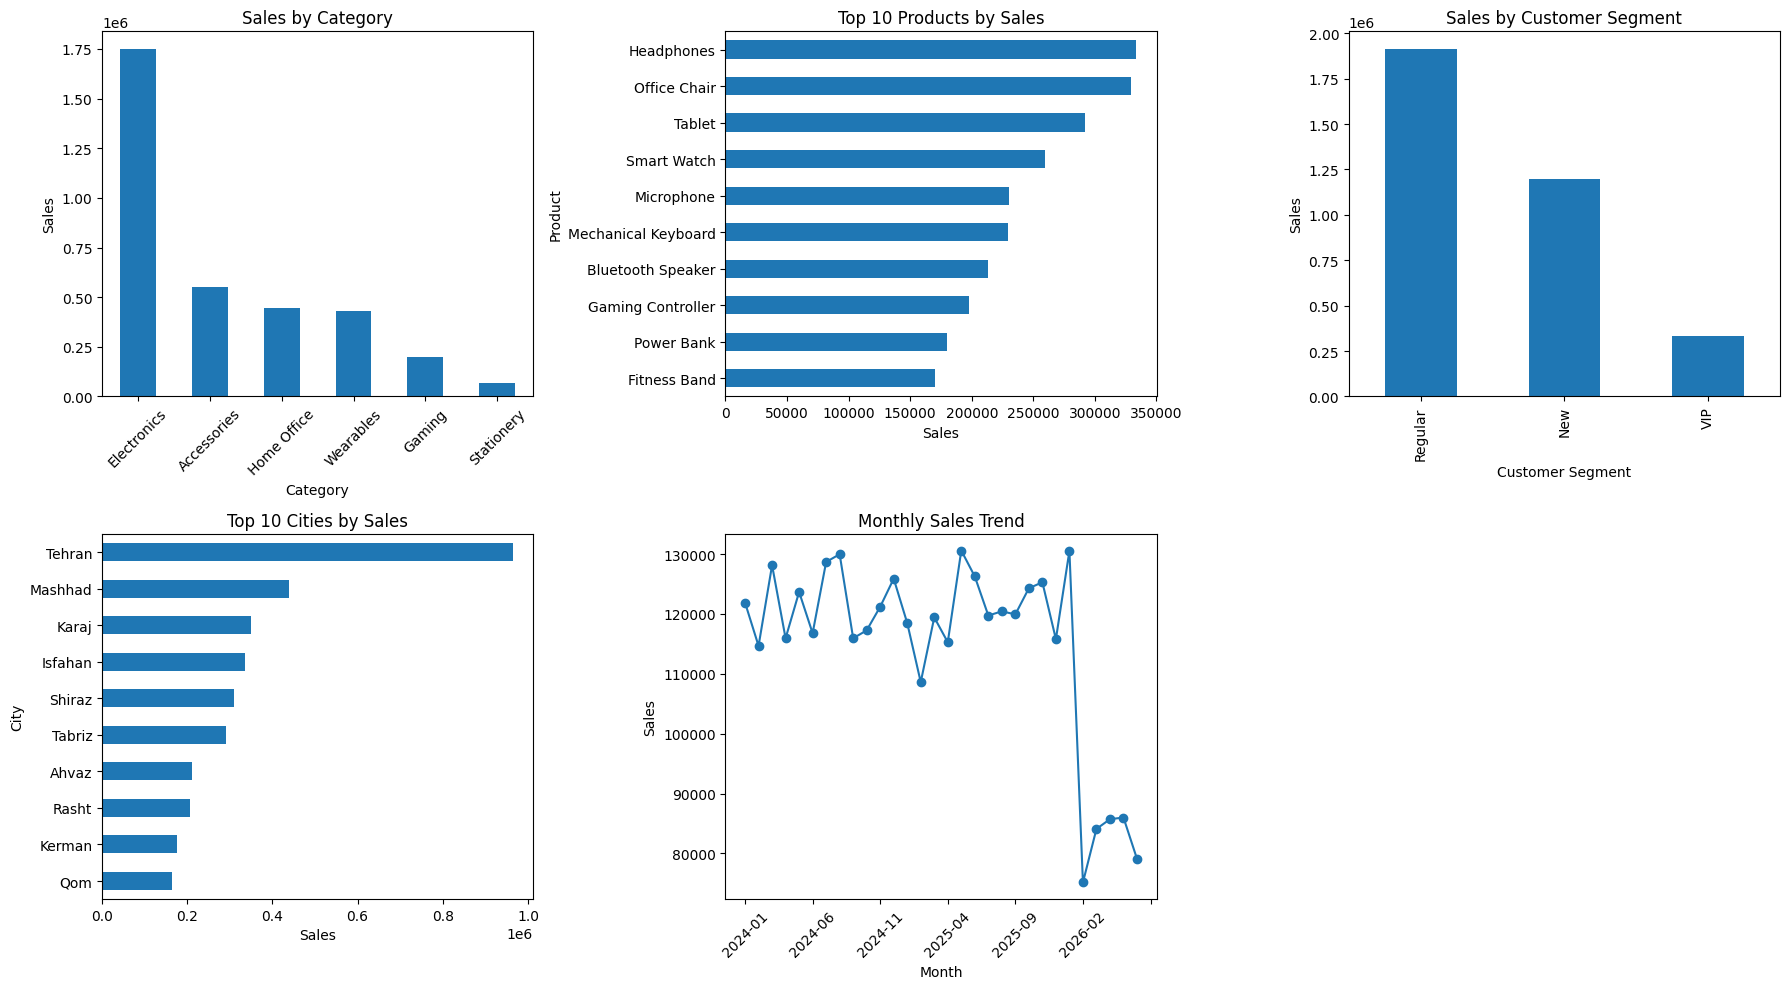

In [20]:
# Create essential visualizations

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Sales by Category
category_sales.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Sales by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Sales")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Top 10 Products
top_products.sort_values().plot(kind="barh", ax=axes[0, 1])
axes[0, 1].set_title("Top 10 Products by Sales")
axes[0, 1].set_xlabel("Sales")
axes[0, 1].set_ylabel("Product")

# 3. Customer Segment
segment_sales.plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("Sales by Customer Segment")
axes[0, 2].set_xlabel("Customer Segment")
axes[0, 2].set_ylabel("Sales")

# 4. Top Cities
city_sales.sort_values().plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Cities by Sales")
axes[1, 0].set_xlabel("Sales")
axes[1, 0].set_ylabel("City")

# 5. Monthly Sales
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind="line", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Monthly Sales Trend")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Sales")
axes[1, 1].tick_params(axis="x", rotation=45)

# Empty sixth plot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## 9. Key Findings and Conclusion

### Key Findings

- Electronics generated the highest sales among all categories.
- Regular customers contributed the largest share of total sales.
- The dataset contains 49,222 orders from 9,820 customers.
- Total sales amounted to 3,444,830.
- Monthly sales show how business performance changes over time.

### Conclusion

The analysis provides an overview of ecommerce sales, customer
segments, product performance, geographical sales, and sales trends.
The visualizations help identify important patterns in the dataset
and provide a foundation for further business analysis.